# Метод 2 — MLP. Часть 1: данные и архитектура

In [1]:
from pathlib import Path
import sys

ROOT = Path('/Users/ensamsanovich/auc_forecast')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT_DIR = ROOT / 'outputs' / 'method_2_mlp'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Корневой путь:', ROOT)
print('Папка для PNG:', OUT_DIR)


Корневой путь: /Users/ensamsanovich/auc_forecast
Папка для PNG: /Users/ensamsanovich/auc_forecast/outputs/method_2_mlp


In [2]:
from core.config import SEED, TARGETS, set_seed
from core.runner import load_unified_data
from core.leak_safe_features import build_leak_safe_aggregates

set_seed(SEED)
data = load_unified_data()
split = data['split']
print(f"Train: {len(split['train_idx'])} | Holdout: {len(split['holdout_idx'])}")
print(f"Число CV-фолдов: {len(split['folds'])}")
print(f"Протокол сплита: {split['protocol']}")


Train: 806 | Holdout: 202
Число CV-фолдов: 5
Протокол сплита: time-based 80/20 (sort by hour_start with row_index tiebreaker) + 5-fold campaign CV on train (seed=42)


In [3]:
X = build_leak_safe_aggregates(data['val'], data['user_index'], data['pub_index'])
y = data['ans'][list(TARGETS)].astype(float)
print('Размер матрицы признаков:', X.shape)
print('Целевые столбцы:', list(y.columns))
X.head()


Размер матрицы признаков: (1008, 39)
Целевые столбцы: ['at_least_one', 'at_least_two', 'at_least_three']


,cpm,audience_size,hour_start,hour_end,campaign_duration,num_publishers,hour_start_of_day,hour_end_of_day,coverage_morning,coverage_afternoon,...,pub_median_cpm,pub_std_cpm,pub_mean_age,pub_male_ratio,pub_imp_per_user,pub_premium_ratio,pub_high_volume_ratio,cpm_x_duration,cpm_x_audience,audience_known_ratio
0,220.0,1906,1058,1153,95,2,2,1,0.252632,0.252632,...,104.212498,418.667526,31.013830,0.402830,8.628101,1.000000,0.50,20900.0,419320.0,0.890871
1,312.0,1380,1295,1301,6,2,23,5,0.000000,0.000000,...,88.592499,543.627602,29.367885,0.663655,13.139861,1.000000,0.50,1872.0,430560.0,0.997826
2,70.0,888,1229,1249,20,6,5,1,0.300000,0.300000,...,88.744999,386.876807,28.903716,0.533237,20.141016,0.833333,0.50,1400.0,62160.0,0.902027
3,240.0,440,1295,1377,82,2,23,9,0.256098,0.219512,...,108.750000,334.540634,30.247096,0.612551,23.936595,1.000000,0.50,19680.0,105600.0,0.922727
4,262.0,1476,752,990,238,4,8,6,0.243697,0.252101,...,99.542500,411.514645,31.107511,0.556827,13.006651,1.000000,0.75,62356.0,386712.0,0.802846


## Архитектура ImprovedMLP

Архитектура: три блока `Linear → BatchNorm → ReLU → Dropout` с
размерностями 256 → 128 → 64 и финальный `Linear(64, 3) + Sigmoid`.

In [4]:
import torch
from torch import nn

class ImprovedMLP(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(64, 3), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x)

model = ImprovedMLP(input_dim=X.shape[1])
n_params = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Всего параметров: {n_params:,}')
print(f'Обучаемых параметров: {n_train:,}')
print(model)


Всего параметров: 52,483
Обучаемых параметров: 52,483
ImprovedMLP(
  (net): Sequential(
    (0): Linear(in_features=39, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=3, bias=True)
    (13): Sigmoid()
  )
)


## Функции потерь 

In [5]:
from core.metrics import LOSS_REGISTRY

losses_to_try = ['mse', 'mae', 'huber', 'msle', 'rmsle', 'smlar_smooth']
print('LOSS_REGISTRY содержит:')
for name in losses_to_try:
    assert name in LOSS_REGISTRY, f'нет потерь {name}'
    print(f'  - {name}')


LOSS_REGISTRY содержит:
  - mse
  - mae
  - huber
  - msle
  - rmsle
  - smlar_smooth


## Визуализация архитектуры

12 PNG-кадров, каждый кадр добавляет один слой/блок MLP. Сохраняется в
`outputs/method_2_mlp/fig_arch_step_001.png` … `fig_arch_step_012.png`.

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

input_dim = X.shape[1]
layers = [
    ('Input',           f'Input ({input_dim})',   '#cfe2f3'),
    ('Linear-256',      'Linear(→ 256)',          '#9fc5e8'),
    ('BN+ReLU+Drop-256','BatchNorm + ReLU + Dropout(0.3)', '#6fa8dc'),
    ('Linear-128',      'Linear(256 → 128)',      '#9fc5e8'),
    ('BN+ReLU+Drop-128','BatchNorm + ReLU + Dropout(0.3)', '#6fa8dc'),
    ('Linear-64',       'Linear(128 → 64)',       '#9fc5e8'),
    ('BN+ReLU+Drop-64', 'BatchNorm + ReLU + Dropout(0.3)', '#6fa8dc'),
    ('Linear-3',        'Linear(64 → 3)',         '#f9cb9c'),
    ('Sigmoid',         'Sigmoid',                '#f6b26b'),
    ('Output',          'Output (y1, y2, y3)',    '#b6d7a8'),
    ('Loss',            'Loss = SMLAR-smooth',    '#ea9999'),
    ('Backprop',        'Backprop + AdamW',       '#a4c2f4'),
]

n_frames = len(layers)
for k in range(1, n_frames + 1):
    fig, ax = plt.subplots(figsize=(6.4, 8.4))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, n_frames + 1)
    ax.axis('off')
    for i, (_, label, color) in enumerate(layers[:k]):
        y_pos = n_frames - i
        rect = patches.FancyBboxPatch(
            (1.5, y_pos - 0.4), 7.0, 0.8,
            boxstyle='round,pad=0.05', linewidth=1.0,
            edgecolor='#333333', facecolor=color,
        )
        ax.add_patch(rect)
        ax.text(5.0, y_pos, label, ha='center', va='center', fontsize=11, color='#222222')
        if i > 0:
            ax.annotate('', xy=(5.0, y_pos + 0.4), xytext=(5.0, y_pos + 0.6),
                        arrowprops=dict(arrowstyle='->', color='#555555', lw=1.0))
    ax.set_title(f'ImprovedMLP — шаг {k}/{n_frames}', fontsize=12)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'fig_arch_step_{k:03d}.png', dpi=120, bbox_inches='tight')
    plt.close(fig)
print('Сохранено кадров:', n_frames)


Сохранено кадров: 12


### Финальный кадр архитектуры

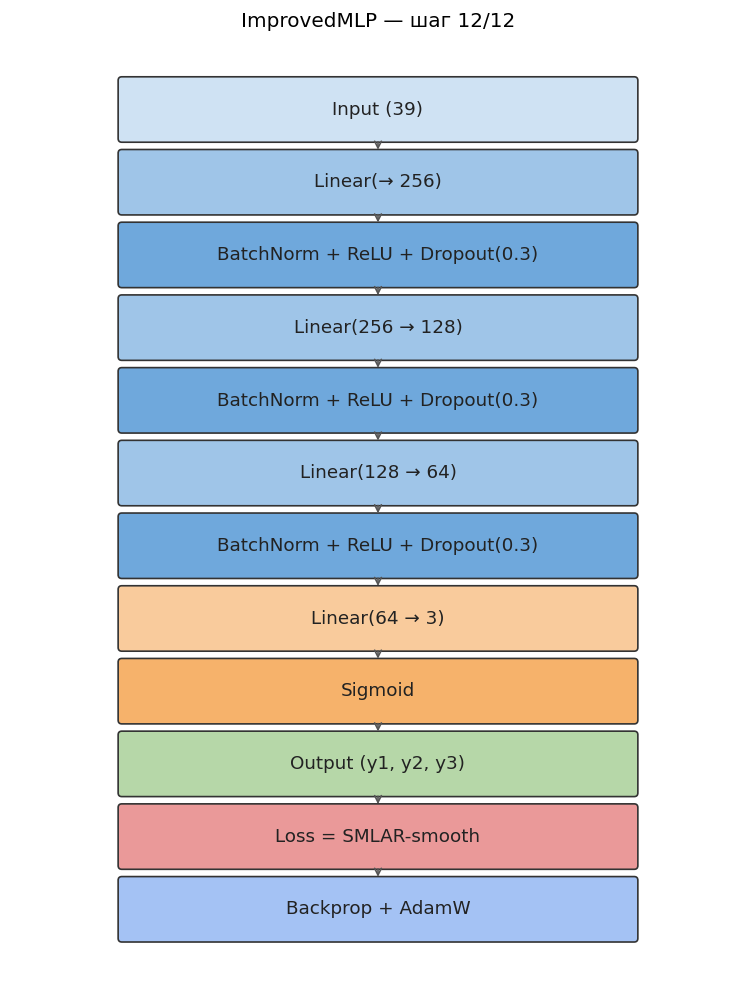

In [7]:
from IPython.display import Image, display
display(Image(filename=str(OUT_DIR / f'fig_arch_step_{n_frames:03d}.png')))
